# Phase 1 – Exploratory Data Analysis
## 1.1 Basic description of the data and its characteristics

Rail Air-Production-Unit (APU) Predictive Maintenance. The target is `failure`.

This section covers A–E of section 1.1: structure, individual attributes, pairwise relationships, relationships with the target, and initial project decisions.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 35)

# Support running from the project folder or the neighbouring IAU workspace.
data_dir = next((base / "141" for base in [
    Path.cwd(), Path.cwd() / "iau_project", Path.cwd() / "IAU-project",
    Path.cwd().parent / "iau_project",
] if all((base / "141" / name).is_file()
         for name in ["readings.csv", "units.csv", "gateways.csv"])), None)
if data_dir is None:
    raise FileNotFoundError("Cannot find all three dataset files in the 141 folder.")

readings = pd.read_csv(data_dir / "readings.csv", sep="\t")
units = pd.read_csv(data_dir / "units.csv", sep=",")
gateways = pd.read_csv(data_dir / "gateways.csv", sep=";")
datasets = {"readings": readings, "units": units, "gateways": gateways}

### A – Structure of the files and records

There are three text/CSV files, with different separators. `readings.csv` contains repeated sensor observations and the target. `units.csv` describes individual APU units. `gateways.csv` describes communication gateway records, some of which are linked to a unit. The common `unitId` needs format alignment before a join; `depotId` is a category, not a unique join key.

In [2]:
file_summary = pd.DataFrame([
    {"file": name + ".csv", "separator": sep,
     "size_KiB": round((data_dir / (name + ".csv")).stat().st_size / 1024, 1),
     "records": len(df), "attributes": df.shape[1]}
    for (name, df), sep in zip(datasets.items(), ["tab", "comma", "semicolon"])
])
display(file_summary)
for name, df in datasets.items():
    print(f"\n{name}: {df.shape}")
    df.info()
    display(df.head())
    display(df.tail())
    display(df.sample(5, random_state=42))

,file,separator,size_KiB,records,attributes
0,readings.csv,tab,1464.5,15080,12
1,units.csv,comma,179.2,2000,11
2,gateways.csv,semicolon,1383.3,16000,9



readings: (15080, 12)
<class 'pandas.DataFrame'>
RangeIndex: 15080 entries, 0 to 15079
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   unitId              15080 non-null  str    
 1   tsCycle             15080 non-null  str    
 2   current_motor       15080 non-null  float64
 3   dp_filter           14481 non-null  float64
 4   oilTemperature      15080 non-null  float64
 5   reservoir_pressure  15080 non-null  float64
 6   vibration_rms       14486 non-null  float64
 7   Flowmeter           15080 non-null  float64
 8   temp_bearing        15080 non-null  float64
 9   dewpointDischarge   15080 non-null  float64
 10  auxCurrent          15080 non-null  float64
 11  failure             15080 non-null  int64  
dtypes: float64(9), int64(1), str(2)
memory usage: 1.6 MB


,unitId,tsCycle,current_motor,dp_filter,oilTemperature,reservoir_pressure,vibration_rms,Flowmeter,temp_bearing,dewpointDischarge,auxCurrent,failure
0,U00446,12 Nov 2023,4.38454,26.89302,65.11293,8.86318,2.06751,26.44157,70.62623,6.31825,1.88395,0
1,U00406,2023-09-25,6.49560,10.29036,58.61599,8.19517,1.21185,26.04481,73.12358,16.95198,3.59209,0
2,U00045,06 May 2023,5.62191,28.10412,53.73762,7.86230,1.74962,36.58353,61.40743,6.09235,2.22038,0
3,U01178,23 Jun 2023,7.02885,27.00850,47.26967,8.99546,7.28034,28.66149,62.33382,11.94870,2.14021,0
4,U01900,2023-12-24,4.70894,30.38483,56.61160,7.93272,2.14559,27.91020,69.58315,10.99307,3.22927,0


,unitId,tsCycle,current_motor,dp_filter,oilTemperature,reservoir_pressure,vibration_rms,Flowmeter,temp_bearing,dewpointDischarge,auxCurrent,failure
15075,U01213,2023/03/08,4.93386,9.93896,60.39918,8.94825,5.15784,26.62232,61.71193,10.66403,2.41832,0
15076,U01005,2023-03-01,1.71314,11.93049,38.38982,9.73995,4.70392,30.29301,68.70938,7.60592,3.49486,0
15077,U00354,2023-02-05,8.29955,15.75189,46.07816,8.09865,1.48666,26.61279,68.47799,4.24286,3.95096,0
15078,U01360,2023/07/22,7.43244,26.64924,68.79975,9.02678,9.73629,30.56478,50.78740,10.48284,0.95466,0
15079,U00147,2023/08/25,5.99962,32.51650,52.41795,8.74057,1.16696,25.29716,55.43718,9.59663,2.26494,1


,unitId,tsCycle,current_motor,dp_filter,oilTemperature,reservoir_pressure,vibration_rms,Flowmeter,temp_bearing,dewpointDischarge,auxCurrent,failure
5404,U01600,2023-04-08,4.60906,29.98704,59.05190,8.43095,4.10877,34.78044,72.78555,10.19446,3.07080,0
3613,U00286,"10/11/2023, 00:05:00",4.62617,18.89023,29.58406,8.42325,1.11558,26.43817,66.24214,7.82546,2.39157,0
7634,U01129,2023/08/27,7.34437,27.12936,51.01071,8.62130,2.13742,30.50964,62.37525,6.43555,3.11528,0
9942,U00831,2023/06/23,2.83488,13.63877,62.37241,9.94450,2.75211,38.75975,74.43241,7.88450,2.09370,0
5221,U00488,2023/10/07,7.40017,12.51867,62.65481,9.59852,1.47939,32.63241,66.08998,11.03653,2.31832,0


...

,class_duty,serialNumber,depotId,Manufacturer,operator_owner,overhaulLast,unitId,model_code,commissionYear,hours_service,fleet_code
1860,1,CI-4341-05463,17,Reis,Dowerg,15 Jul 2020,1861,APU-20,2022,7234.7,FD
353,H,PC-6226-17152,25,Correia S/A,Harris-Moore,2023/07/07,354,APU-12,2022,10268.3,FC
1333,light,TZ-7949-27784,16,Leal S.A.,Barros,27 Mar 2023,1334,APU-20,2022,7743.0,FE
905,3,RQ-5155-53427,98,Hübel Ebert GmbH,Franke AG,2021-02-05,906,APU-15,2016,30150.9,FD
1289,H,XH-2567-36748,108,Valente S.A.,Mälzer,2024-09-28,1290,APU-15,2018,21282.1,FC



gateways: (16000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   vendor            16000 non-null  str    
 1   firmware_version  16000 non-null  str    
 2   Ipv4              16000 non-null  str    
 3   unitId            2000 non-null   float64
 4   depotId           16000 non-null  int64  
 5   signalDbm         16000 non-null  float64
 6   technician        16000 non-null  str    
 7   gatewayId         16000 non-null  str    
 8   lastSeen          16000 non-null  str    
dtypes: float64(2), int64(1), str(6)
memory usage: 2.1 MB


,vendor,firmware_version,Ipv4,unitId,depotId,signalDbm,technician,gatewayId,lastSeen
0,Paiva e Filhos,v1.2.5,240.222.226.112,1613.0,96,-61.0,Gaspar Gomes-Faria,GW-00000,2024-08-20
1,Carlson-Spears,v3.4.1,180.162.46.233,1693.0,52,-53.1,Dorit Nohlmans,GW-00001,"01/26/2024, 00:00:00"
2,Correia S/A,v3.4.1,181.63.29.198,1492.0,19,-68.6,Stacy Wolfe,GW-00002,14 Dec 2024
3,Rosenow GmbH & Co. KGaA,v2.7.0,158.184.142.148,903.0,64,-67.3,Ing. Francoise Carsten,GW-00003,2024/12/13
4,Cardoso,v2.7.0,200.236.47.63,935.0,29,-58.2,Pedro Costa,GW-00004,2024-05-14


,vendor,firmware_version,Ipv4,unitId,depotId,signalDbm,technician,gatewayId,lastSeen
15995,Coleman-Sanford,v3.4.1,44.75.88.240,NaN,23,-52.5,Timothy Larsen,GW-15995,03 May 2024
15996,Maia S/A,v1.2.5,137.222.49.158,NaN,98,-78.9,Pedro Costa,GW-15996,04 Aug 2024
15997,Villanueva-Flynn,v2.7.0,50.38.25.84,NaN,76,-80.1,Suzanne Schacht,GW-15997,"11/24/2024, 00:00:00"
15998,Rosenow GmbH & Co. KGaA,v3.4.1,168.129.77.228,NaN,0,-73.5,Keith Rodriguez,GW-15998,2024/04/25
15999,Cardoso,v2.7.0,55.186.204.156,NaN,58,-67.8,Robert Taylor,GW-15999,"09/21/2024, 00:00:00"


,vendor,firmware_version,Ipv4,unitId,depotId,signalDbm,technician,gatewayId,lastSeen
8756,Moreira,v3.4.1,86.152.6.178,NaN,11,-69.1,Beata Margraf,GW-08756,"05/23/2024, 00:00:00"
4660,Barnett-Stone,v1.2.5,183.29.225.169,NaN,68,-56.5,Ing. Joanna Steinberg B.Sc.,GW-04660,20 Oct 2024
6095,Pinto,v1.2.5,90.33.95.98,NaN,62,-68.4,Bárbara Matos,GW-06095,"10/19/2024, 00:00:00"
304,"Nguyen, Freeman and Roy",v1.2.5,100.209.252.20,171.0,74,-59.3,Inken Steckel,GW-00304,2024/07/30
8241,Reis,v1.2.5,144.123.126.178,NaN,6,-65.6,Randy Quinn,GW-08241,28 Jul 2024


In [3]:
schema = pd.concat([
    pd.DataFrame({"file": name, "attribute": df.columns,
                  "loaded_dtype": df.dtypes.astype(str).to_numpy(),
                  "non_null": df.notna().sum().to_numpy(),
                  "unique_non_null": df.nunique().to_numpy()})
    for name, df in datasets.items()
], ignore_index=True)
display(schema)

,file,attribute,loaded_dtype,non_null,unique_non_null
0,readings,unitId,str,15080,2124
1,readings,tsCycle,str,15080,4749
2,readings,current_motor,float64,15080,14662
3,readings,dp_filter,float64,14481,14236
4,readings,oilTemperature,float64,15080,14770
5,readings,reservoir_pressure,float64,15080,14332
6,readings,vibration_rms,float64,14486,14063
7,readings,Flowmeter,float64,15080,14752
8,readings,temp_bearing,float64,15080,14816
9,readings,dewpointDischarge,float64,15080,14751


The tables contain 15,080 × 12 readings, 2,000 × 11 units, and 16,000 × 9 gateways. The readings have nine numerical sensor attributes, a binary target, a unit identifier, and a cycle timestamp.

Dates currently load as strings. `readings.unitId` uses values such as `U00446`, whereas `units.unitId` is an integer. `gateways.unitId` loads as a float because it also contains missing values. Identifier numbers, depot numbers, IP addresses, and serial numbers should be interpreted as identifiers/categories rather than continuous measurements.

In [4]:
quality_summary = pd.DataFrame({
    "records": {name: len(df) for name, df in datasets.items()},
    "exact_duplicate_rows": {name: df.duplicated().sum() for name, df in datasets.items()},
    "rows_with_any_missing_value": {name: df.isna().any(axis=1).sum() for name, df in datasets.items()},
})
display(quality_summary)
for name, df in datasets.items():
    print(name)
    display(pd.DataFrame({"missing_count": df.isna().sum(),
                          "missing_percent": 100 * df.isna().mean()}).round(2))
display(readings.loc[readings.duplicated(keep=False)].head(10))

,records,exact_duplicate_rows,rows_with_any_missing_value
readings,15080,223,1124
units,2000,0,100
gateways,16000,0,14000


readings


,missing_count,missing_percent
unitId,0,0.00
tsCycle,0,0.00
current_motor,0,0.00
dp_filter,599,3.97
oilTemperature,0,0.00
reservoir_pressure,0,0.00
vibration_rms,594,3.94
Flowmeter,0,0.00
temp_bearing,0,0.00
dewpointDischarge,0,0.00


units


,missing_count,missing_percent
class_duty,0,0.0
serialNumber,0,0.0
depotId,0,0.0
Manufacturer,0,0.0
operator_owner,0,0.0
overhaulLast,0,0.0
unitId,0,0.0
model_code,0,0.0
commissionYear,0,0.0
hours_service,100,5.0


gateways


,missing_count,missing_percent
vendor,0,0.0
firmware_version,0,0.0
Ipv4,0,0.0
unitId,14000,87.5
depotId,0,0.0
signalDbm,0,0.0
technician,0,0.0
gatewayId,0,0.0
lastSeen,0,0.0


,unitId,tsCycle,current_motor,dp_filter,oilTemperature,reservoir_pressure,vibration_rms,Flowmeter,temp_bearing,dewpointDischarge,auxCurrent,failure
106,U01188,2023/06/24,4.65822,15.46873,69.71626,8.11583,1.94103,22.46048,75.41285,7.30902,1.89418,0
316,U01706,2023-02-18,3.86833,18.21695,56.47784,8.74451,4.70414,24.27993,79.64657,5.88904,2.88916,0
372,U01336,2023-08-30,1.95983,15.79545,67.18218,8.58638,3.43546,21.85071,54.90365,7.16934,1.99725,0
407,U00635,"09/02/2023, 08:01:00",4.25991,82.83838,55.75462,8.29768,5.92615,27.51389,70.44865,6.39902,2.66165,0
613,U00251,19 Jan 2023,3.25347,27.79946,48.08867,8.81066,0.82609,23.23798,52.62063,6.74992,1.73029,0
642,U00045,2023-03-26,5.22721,33.15209,45.74798,9.98749,5.61039,29.06318,68.10910,2.86291,3.60526,0
847,U01332,2023-07-09,3.78956,25.18440,58.24186,7.76857,4.29372,29.55898,58.07436,10.02358,2.58214,0
897,U01730,2023-06-12,7.84989,24.19449,66.26480,9.01843,2.63142,32.69166,68.69489,6.33286,2.94626,0
918,U01073,2023/08/18,3.85061,29.41959,56.63758,9.77019,3.93217,24.19166,69.06940,6.49014,2.98476,0
973,U00811,2023-06-29,5.15419,50.06800,50.26308,9.06532,2.23786,19.48125,60.31601,5.49595,2.08212,0


There are 223 exact duplicate reading rows. `dp_filter` has 599 missing values and `vibration_rms` has 594. Unit service hours are missing for 100 / 2,000 units (5%). Gateway `unitId` is missing for 14,000 / 16,000 gateways (87.5%), dropping all incomplete gateway rows would discard most of the table. These observations will guide section 1.2.

#### Dates and relationships between files

For a structural check, datetime is more appropriate than strings because it allows chronological comparisons. We preserve the original columns and parse separate copies using the four observed formats. Month-first slash dates are identified by their comma/time format.

In [5]:
def parse_dates(values):
    parsed = pd.Series(pd.NaT, index=values.index, dtype="datetime64[ns]")
    for fmt in ["%Y-%m-%d", "%m/%d/%Y, %H:%M:%S", "%d %b %Y", "%Y/%m/%d"]:
        parsed = parsed.fillna(pd.to_datetime(values.str.strip(), format=fmt, errors="coerce"))
    return parsed

readings_eda = readings.copy()
units_eda = units.copy()
gateways_eda = gateways.copy()
readings_eda["unit_key"] = pd.to_numeric(
    readings_eda["unitId"].str.extract(r"^U(\d{5})$", expand=False),
    errors="coerce").astype("Int64")
units_eda["unit_key"] = units_eda["unitId"].astype("Int64")
gateways_eda["unit_key"] = gateways_eda["unitId"].astype("Int64")

date_summary = []
for name, df, col in [("readings", readings_eda, "tsCycle"),
                      ("units", units_eda, "overhaulLast"),
                      ("gateways", gateways_eda, "lastSeen")]:
    df[col + "_date"] = parse_dates(df[col])
    date_summary.append({"file": name, "attribute": col,
                         "unparsed_non_null": (df[col].notna() & df[col + "_date"].isna()).sum(),
                         "earliest": df[col + "_date"].min(), "latest": df[col + "_date"].max()})
display(pd.DataFrame(date_summary))
display(pd.DataFrame({"file": list(datasets),
                      "missing_or_unparsed_unit_key": [readings_eda.unit_key.isna().sum(),
                          units_eda.unit_key.isna().sum(), gateways_eda.unit_key.isna().sum()],
                      "unique_linked_units": [readings_eda.unit_key.nunique(),
                          units_eda.unit_key.nunique(), gateways_eda.unit_key.nunique()]}))

,file,attribute,unparsed_non_null,earliest,latest
0,readings,tsCycle,0,2023-01-01,2023-12-31 19:45:00
1,units,overhaulLast,0,2015-01-02,2024-12-26 00:00:00
2,gateways,lastSeen,0,2024-01-01,2025-02-03 00:00:00


,file,missing_or_unparsed_unit_key,unique_linked_units
0,readings,0,2124
1,units,0,2000
2,gateways,14000,2000


In [6]:
# Check cardinality before joining
linked_gateways = gateways_eda.loc[gateways_eda["unit_key"].notna()].copy()
assert units_eda["unit_key"].is_unique
assert linked_gateways["unit_key"].is_unique
eda = readings_eda.merge(
    units_eda.drop(columns="unitId"), on="unit_key", how="left",
    validate="many_to_one", indicator="unit_match")
assert len(eda) == len(readings)
display(eda["unit_match"].value_counts())
display(eda.loc[eda["unit_match"].eq("left_only"), ["unitId", "tsCycle", "failure"]].head(10))

gateway_links = linked_gateways.merge(
    units_eda[["unit_key", "depotId"]], on="unit_key", how="left",
    suffixes=("_gateway", "_unit"), validate="one_to_one", indicator=True)
display(gateway_links["_merge"].value_counts())
print("Linked gateways with different unit/gateway depot:",
      gateway_links.loc[gateway_links["_merge"].eq("both"), "depotId_gateway"].ne(
          gateway_links.loc[gateway_links["_merge"].eq("both"), "depotId_unit"]).sum())
print("Repeated unit + parsed timestamp rows:",
      readings_eda.duplicated(["unit_key", "tsCycle_date"]).sum())
display(readings_eda.groupby("unit_key").size().describe().rename("readings_per_unit"))

unit_match
both          14936
left_only       144
right_only        0
Name: count, dtype: int64

,unitId,tsCycle,failure
133,U90125,2023/10/10,0
231,U90190,2023-04-03,0
406,U90303,2023/10/12,0
475,U90035,2023-08-10,0
744,U90250,2023/09/25,0
1048,U90259,05 Oct 2023,0
1068,U90402,2023-02-23,0
1212,U90106,2023-01-07,0
1341,U90101,2023/03/10,0
1400,U90400,2023/05/01,0


_merge
both          2000
left_only        0
right_only       0
Name: count, dtype: int64

Linked gateways with different unit/gateway depot: 0
Repeated unit + parsed timestamp rows: 291


count    2124.000000
mean        7.099812
std         3.105375
min         1.000000
25%         5.000000
50%         7.000000
75%         9.000000
max        17.000000
Name: readings_per_unit, dtype: float64

The readings cover 2023-01-01 to 2023-12-31, while gateway `lastSeen` covers 2024-01-01 to 2025-02-03.

There are 2,124 distinct reading unit IDs, but only 2,000 units in the metadata. The left join matches 14,936 readings and leaves 144 unmatched (124 distinct IDs). Each of the 2,000 assigned gateways links to a different known unit, with no depot disagreement. Thus readings → units is many-to-one and units → assigned gateways is one-to-one in this dataset. Joining by depot alone would multiply records because depots contain multiple units and gateways.

There are 291 repeated unit/timestamp rows after date parsing, compared with 223 exact duplicate rows. A repeated timestamp by itself does not establish a duplicate. Some dates have no time of day. Most units have multiple observations, which matters when splitting data.

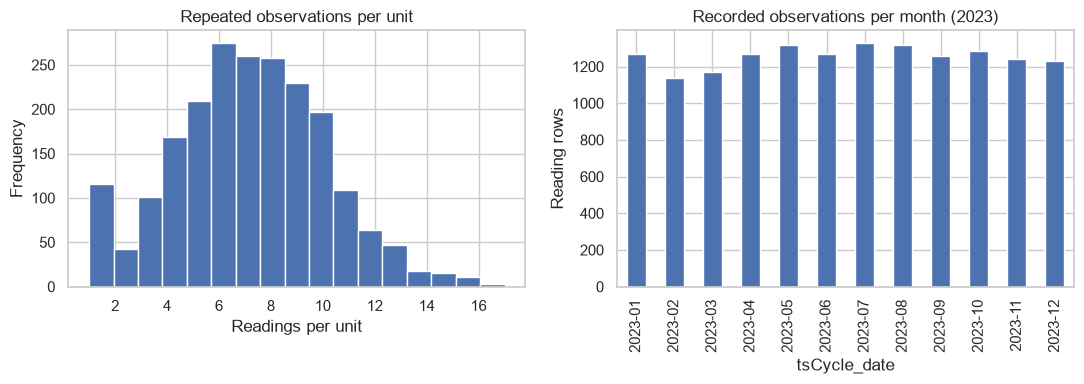

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
readings_eda.groupby("unit_key").size().plot.hist(bins=17, ax=axes[0])
axes[0].set_xlabel("Readings per unit")
axes[0].set_title("Repeated observations per unit")
readings_eda.groupby(readings_eda["tsCycle_date"].dt.to_period("M")).size().plot.bar(ax=axes[1])
axes[1].set_ylabel("Reading rows")
axes[1].set_title("Recorded observations per month (2023)")
plt.tight_layout()
plt.show()

### B – Individual attributes: distributions, statistics, and value conditions

We examine 12 numerical attributes: all nine sensors (`current_motor`, `dp_filter`, `oilTemperature`, `reservoir_pressure`, `vibration_rms`, `Flowmeter`, `temp_bearing`, `dewpointDischarge`, `auxCurrent`) plus `hours_service`, `commissionYear`, and `signalDbm`. We also describe `failure` and relevant categorical metadata.

Sensor units and manufacturer operating limits are not provided. Therefore, the checks below only distinguish observed ranges from simple plausibility conditions. `commissionYear` is an ordered calendar attribute rather than a continuous sensor.

In [8]:
sensor_cols = ["current_motor", "dp_filter", "oilTemperature", "reservoir_pressure",
               "vibration_rms", "Flowmeter", "temp_bearing", "dewpointDischarge", "auxCurrent"]
readings_num_cols = sensor_cols + ["failure"]
units_num_cols = ["hours_service", "commissionYear"]
gateways_num_cols = ["signalDbm"]
units_cat_cols = ["class_duty", "model_code", "fleet_code", "Manufacturer", "operator_owner"]
gateways_cat_cols = ["firmware_version", "vendor"]

display(readings[readings_num_cols].describe().T)
display(pd.DataFrame({"median": readings[sensor_cols].median(),
                      "skew": readings[sensor_cols].skew(),
                      "unique_values": readings[sensor_cols].nunique()}))
display(units[units_num_cols].describe().T)
display(pd.DataFrame({"median": units[units_num_cols].median(),
                      "skew": units[units_num_cols].skew(),
                      "unique_values": units[units_num_cols].nunique()}))
display(gateways[gateways_num_cols].describe().T)
display(pd.DataFrame({"median": gateways[gateways_num_cols].median(),
                      "skew": gateways[gateways_num_cols].skew(),
                      "unique_values": gateways[gateways_num_cols].nunique()}))

,count,mean,std,min,25%,50%,75%,max
current_motor,15080.0,5.283390,3.786114,0.00000,3.713885,5.059550,6.520285,99.00000
dp_filter,14481.0,24.018395,11.268829,7.53417,16.204830,21.321710,28.827840,120.00000
oilTemperature,15080.0,51.415378,62.897813,-999.00000,47.037937,54.988035,62.991835,95.00000
reservoir_pressure,15080.0,8.696196,0.596924,6.60690,8.296143,8.691740,9.097525,10.50000
vibration_rms,14486.0,3.104425,1.660599,0.50000,1.948520,2.716215,3.859410,14.00000
Flowmeter,15080.0,28.044968,3.981177,15.00000,25.403878,28.002550,30.768060,40.00000
temp_bearing,15080.0,64.946440,8.091200,33.66844,59.441710,64.908325,70.373128,99.28025
dewpointDischarge,15080.0,8.014415,3.483870,-8.31939,5.684460,8.035255,10.354430,24.26403
auxCurrent,15080.0,2.502903,0.824380,0.00000,1.936307,2.501630,3.056650,5.56839
failure,15080.0,0.124072,0.329674,0.00000,0.000000,0.000000,0.000000,1.00000


,median,skew,unique_values
current_motor,5.059550,19.112050,14662
dp_filter,21.321710,1.948563,14236
oilTemperature,54.988035,-16.058288,14770
reservoir_pressure,8.691740,0.007464,14332
vibration_rms,2.716215,1.623323,14063
Flowmeter,28.002550,-0.006071,14752
temp_bearing,64.908325,0.032884,14816
dewpointDischarge,8.035255,-0.033408,14751
auxCurrent,2.501630,0.015211,14456


,count,mean,std,min,25%,50%,75%,max
hours_service,1900.0,14235.295474,8497.917754,2076.1,8255.45,12218.65,17991.125,45000.0
commissionYear,2000.0,2020.459000,2.423686,2012.0,2019.00,2021.00,2022.000,2024.0


,median,skew,unique_values
hours_service,12218.65,1.467408,1864
commissionYear,2021.00,-1.397264,13


,count,mean,std,min,25%,50%,75%,max
signalDbm,16000.0,-70.127425,9.971624,-110.0,-76.825,-70.2,-63.4,-40.0


,median,skew,unique_values
signalDbm,-70.2,0.0014,598


In [9]:
# Simple conditions inferred from attribute meanings
checks = []
nonnegative = ["current_motor", "dp_filter", "reservoir_pressure", "vibration_rms", "Flowmeter", "auxCurrent", "oilTemperature"]
for name, df, cols in [("readings", readings, sensor_cols),
                      ("units", units, units_num_cols),
                      ("gateways", gateways, gateways_num_cols)]:
    for col in cols:
        values = df[col]
        if col in nonnegative or col == "hours_service":
            condition, flagged = "Non-negative", values.lt(0)
        elif col == "signalDbm":
            condition, flagged = "Negative in this dataset", values.ge(0)
        elif col == "commissionYear":
            condition, flagged = "Whole calendar year", values.mod(1).ne(0) & values.notna()
        else:
            condition, flagged = "No supplied acceptable range", pd.Series(False, index=df.index)
        checks.append({"file": name, "attribute": col, "min": values.min(),
                       "max": values.max(), "missing": values.isna().sum(),
                       "condition": condition, "flagged_non_null": flagged.sum()})
display(pd.DataFrame(checks))
print("Target values outside {0, 1}:", (~readings["failure"].isin([0, 1])).sum())
display(pd.Series({"oilTemperature = -999": readings.oilTemperature.lt(0).sum(),
                   "current_motor = 0": readings.current_motor.eq(0).sum(),
                   "current_motor = 99": readings.current_motor.eq(99).sum(),
                   "dp_filter = 120": readings.dp_filter.eq(120).sum()}, name="rows_for_inspection"))

,file,attribute,min,max,missing,condition,flagged_non_null
0,readings,current_motor,0.00000,99.00000,0,Non-negative,0
1,readings,dp_filter,7.53417,120.00000,599,Non-negative,0
2,readings,oilTemperature,-999.00000,95.00000,0,Non-negative,52
3,readings,reservoir_pressure,6.60690,10.50000,0,Non-negative,0
4,readings,vibration_rms,0.50000,14.00000,594,Non-negative,0
5,readings,Flowmeter,15.00000,40.00000,0,Non-negative,0
6,readings,temp_bearing,33.66844,99.28025,0,No supplied acceptable range,0
7,readings,dewpointDischarge,-8.31939,24.26403,0,No supplied acceptable range,0
8,readings,auxCurrent,0.00000,5.56839,0,Non-negative,0
9,units,hours_service,2076.10000,45000.00000,100,Non-negative,0


Target values outside {0, 1}: 0


oilTemperature = -999    52
current_motor = 0         1
current_motor = 99       19
dp_filter = 120           4
Name: rows_for_inspection, dtype: int64

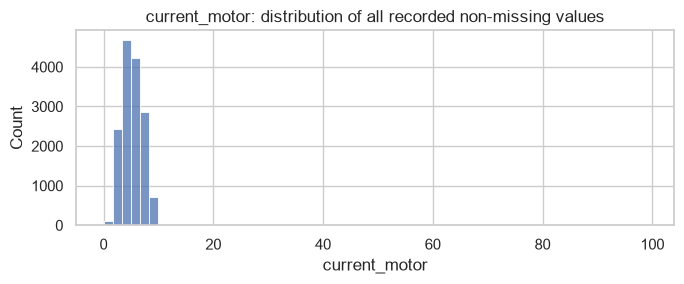

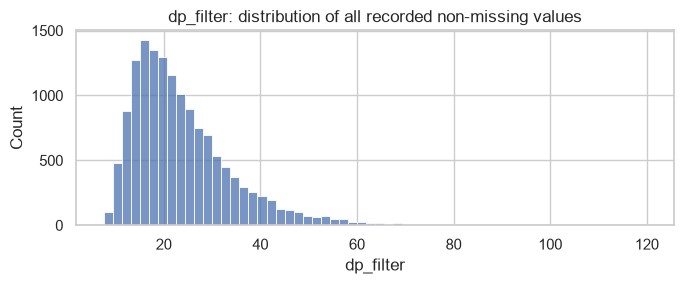

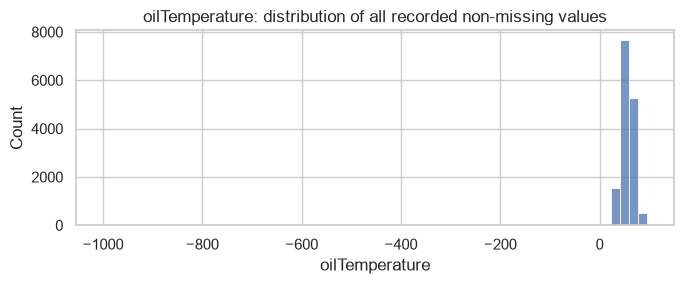

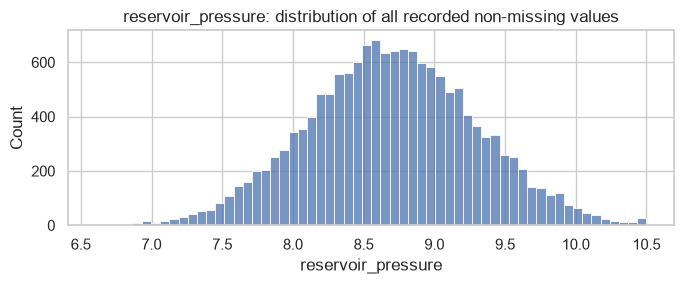

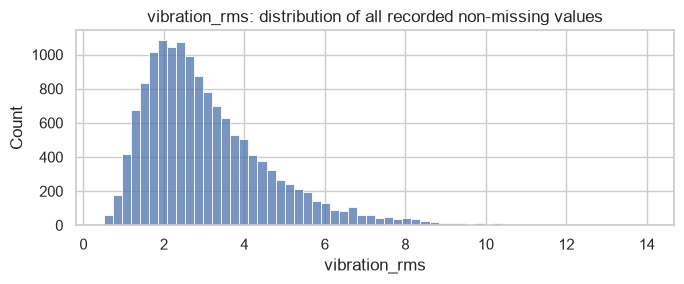

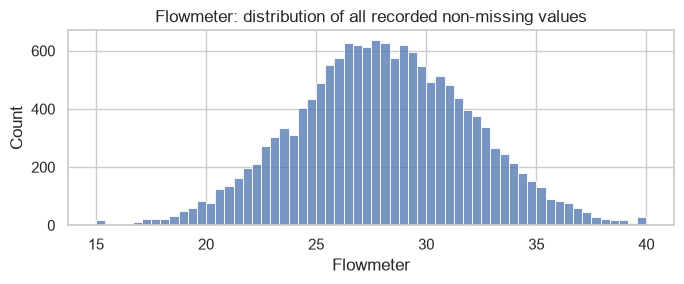

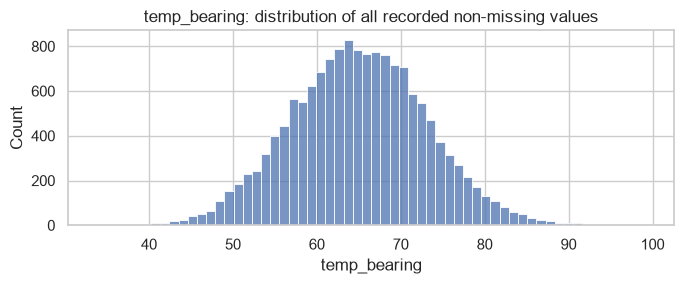

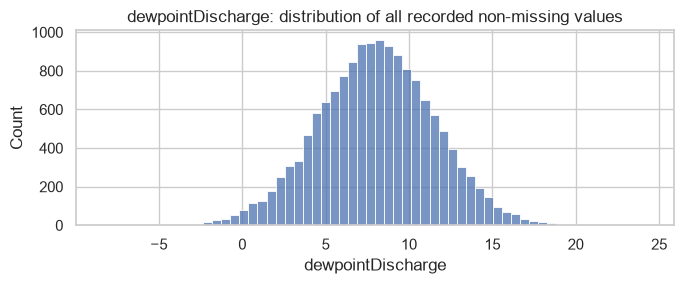

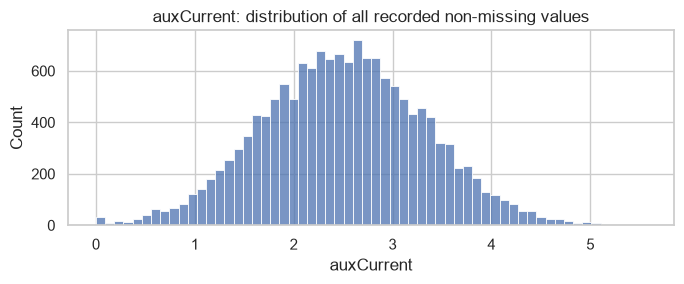

In [10]:
for col in sensor_cols:
    plt.figure(figsize=(7, 3))
    sns.histplot(data=readings, x=col, bins=60)
    plt.title(f"{col}: distribution of all recorded non-missing values")
    plt.tight_layout()
    plt.show()

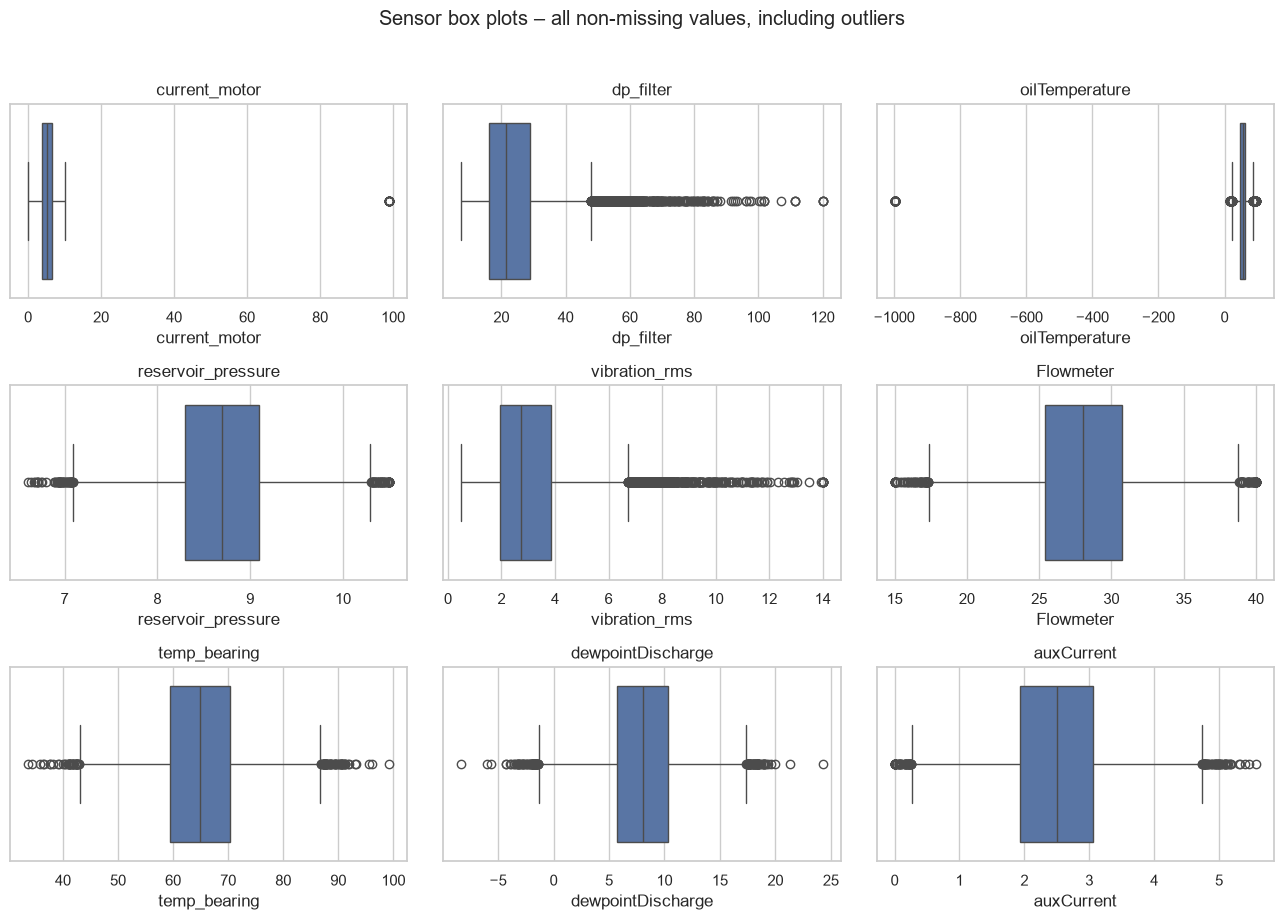

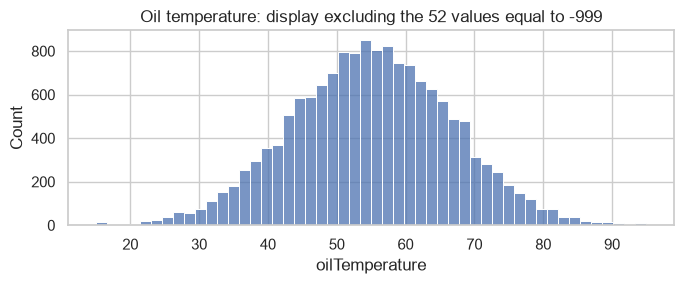

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for col, ax in zip(sensor_cols, axes.flat):
    sns.boxplot(data=readings, x=col, ax=ax)
    ax.set_title(col)
plt.suptitle("Sensor box plots – all non-missing values, including outliers", y=1.02)
plt.tight_layout()
plt.show()

# Additional view for readability; the original full-range plots remain above.
plt.figure(figsize=(7, 3))
sns.histplot(data=readings.loc[readings.oilTemperature.ne(-999)], x="oilTemperature", bins=50)
plt.title("Oil temperature: display excluding the 52 values equal to -999")
plt.tight_layout()
plt.show()

Most sensor values concentrate in fairly narrow regions: the median reservoir pressure is 8.69, flow is 28.00, bearing temperature is 64.91, and auxiliary current is 2.50 in the recorded units. Filter pressure drop and vibration have right-skewed distributions (mean above median), with upper tails that deserve inspection.

Oil temperature contains 52 values equal to -999, which dominate its spread and reduce its mean to 51.42 despite a median of 54.99. The additional plot makes the remaining distribution visible without changing the analysis data. A repeated extreme code might indicate a missing value. Motor current includes 19 values of 99 and one zero, filter pressure drop includes four values of 120. These need context before deciding whether they are invalid or meaningful readings.

No observed non-missing values violate the simple non-negative conditions. Negative dew points can be meaningful, so they are not automatically invalid.

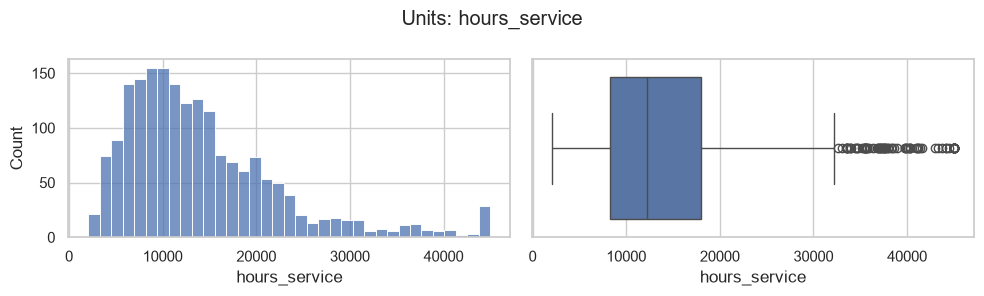

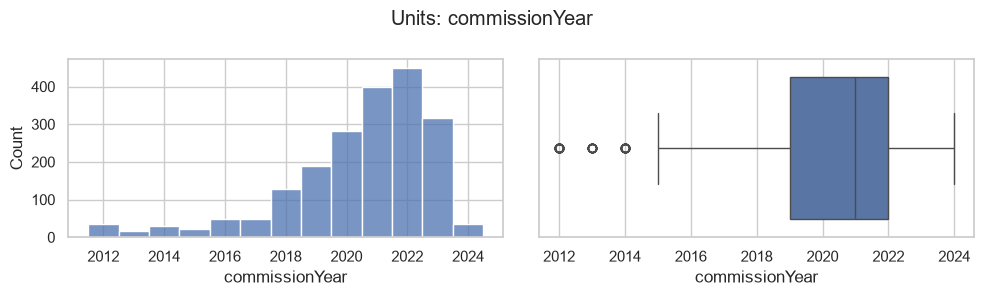

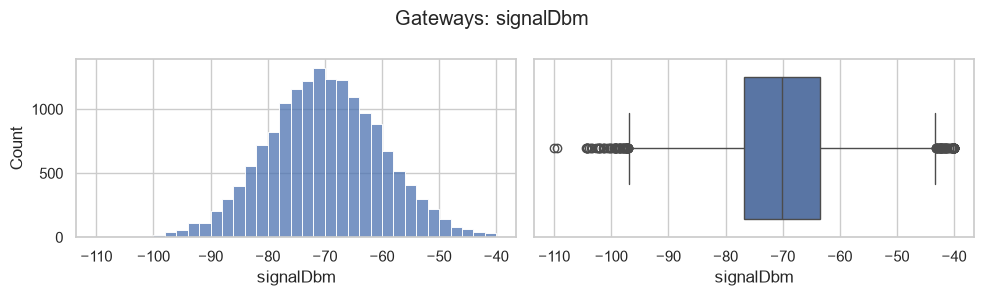

In [12]:
for name, df, cols in [("Units", units, units_num_cols), ("Gateways", gateways, gateways_num_cols)]:
    for col in cols:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        sns.histplot(data=df, x=col, bins=35, discrete=(col == "commissionYear"), ax=axes[0])
        sns.boxplot(data=df, x=col, ax=axes[1])
        fig.suptitle(f"{name}: {col}")
        plt.tight_layout()
        plt.show()

Service hours range from 2,076.1 to 45,000, with a median of 12,218.65 and a higher mean of 14,235.30, indicating a right tail. Commission years range from 2012 to 2024. Gateway signal ranges from -110 to -40, centred near -70. These are distributions in the individual source tables, unit/gateway summaries give each metadata record equal weight, whereas the joined reading table gives frequently observed units more weight.

In [13]:
for name, df, cols in [("Units", units, units_cat_cols), ("Gateways", gateways, gateways_cat_cols)]:
    print(name)
    display(df[cols].nunique())
    for col in cols:
        display(pd.DataFrame({"count": df[col].value_counts(dropna=False),
                              "percent": 100 * df[col].value_counts(normalize=True, dropna=False)}).round(2).rename_axis(col))

Units


class_duty        20
model_code         4
fleet_code         5
Manufacturer      40
operator_owner    40
dtype: int64

,count,percent
class_duty,,
light,254,12.70
L,249,12.45
1,225,11.25
med,172,8.60
normal,163,8.15
2,161,8.05
N,160,8.00
3,153,7.65
heavy,141,7.05


,count,percent
model_code,,
APU-15,515,25.75
XC-7,515,25.75
APU-12,505,25.25
APU-20,465,23.25


,count,percent
fleet_code,,
FD,437,21.85
FC,408,20.40
FB,386,19.30
FA,385,19.25
FE,384,19.20


...

,count,percent
operator_owner,,
Barnett-Stone,60,3.00
Mälzer,60,3.00
Rosenow GmbH & Co. KGaA,58,2.90
Leal S.A.,58,2.90
Borges,57,2.85
Roskoth,57,2.85
Henson Group,57,2.85
Franke AG,57,2.85
Rädel Aumann KGaA,55,2.75


Gateways


firmware_version     3
vendor              40
dtype: int64

,count,percent
firmware_version,,
v2.7.0,5445,34.03
v3.4.1,5412,33.83
v1.2.5,5143,32.14


,count,percent
vendor,,
Junken AG & Co. OHG,437,2.73
Barros,435,2.72
Rädel Aumann KGaA,435,2.72
Mälzer,431,2.69
Brooks Group,424,2.65
Pinto,423,2.64
Borges,421,2.63
Valente S.A.,421,2.63
Maia S/A,420,2.62


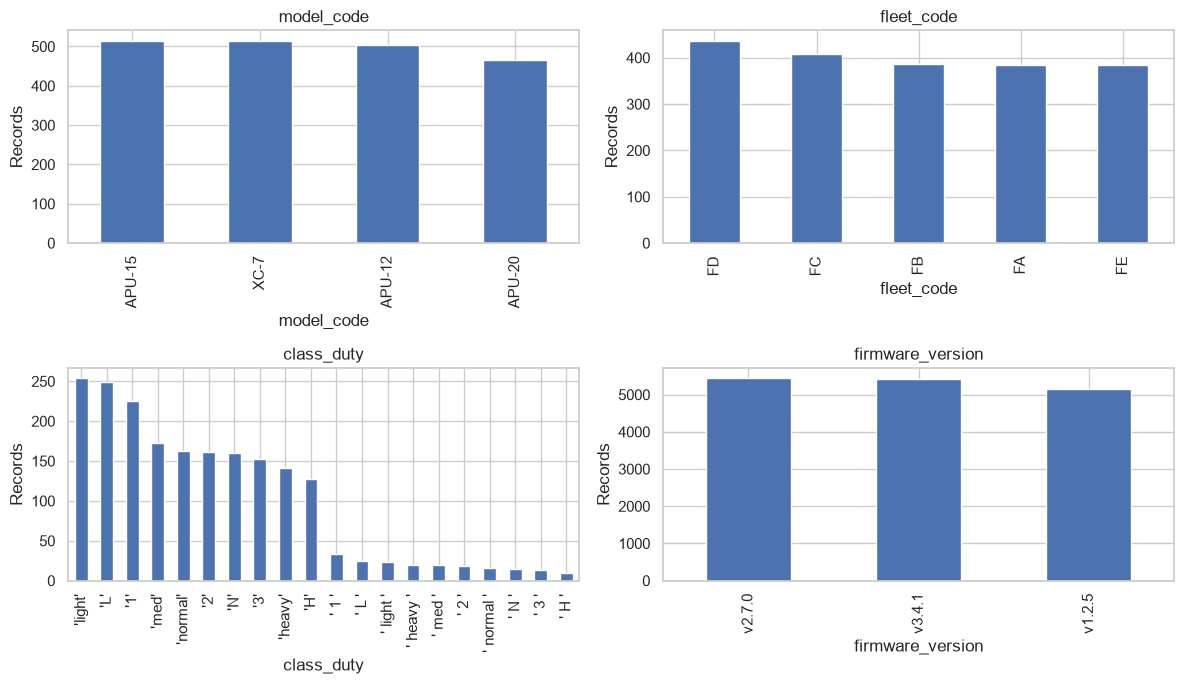

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for (df, col), ax in zip([(units, "model_code"), (units, "fleet_code"),
                          (units, "class_duty"), (gateways, "firmware_version")], axes.flat):
    # repr exposes leading whitespace in the original class labels.
    counts = df[col].value_counts()
    if col == "class_duty":
        counts.index = counts.index.map(repr)
    counts.plot.bar(ax=ax)
    ax.set_ylabel("Records")
    ax.set_title(col)
plt.tight_layout()
plt.show()

There are four APU models, five fleets, and three firmware versions. `class_duty` has 20 raw categories, including leading spaces and probable aliases such as `light`, `L`, and `1`. They will be investigated in section 1.2 before defining a mapping. Manufacturer/vendor and owner each have many categories, while serial numbers and IP addresses are unique identifiers; plotting all identifier frequencies would add little information.

,count,percent
failure,,
0,13209,87.59
1,1871,12.41


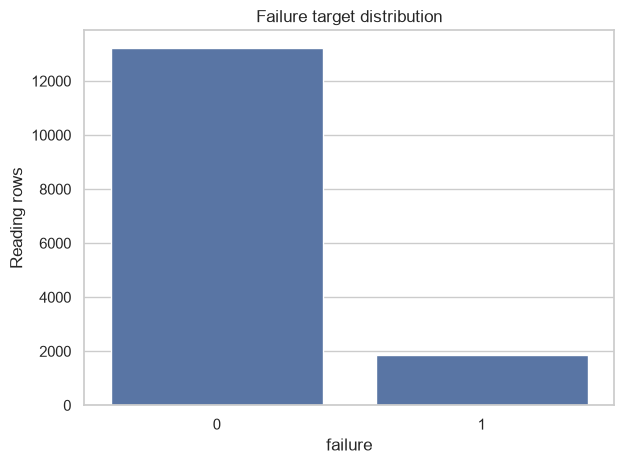

In [15]:
target_counts = readings["failure"].value_counts().sort_index()
display(pd.DataFrame({"count": target_counts, "percent": 100 * target_counts / len(readings)}).round(2))
sns.countplot(data=readings, x="failure", order=[0, 1])
plt.title("Failure target distribution")
plt.ylabel("Reading rows")
plt.tight_layout()
plt.show()

The target is valid and complete: 13,209 rows have failure = 0 (87.59%) and 1,871 have failure = 1 (12.41%). An always-zero classifier would achieve 87.59% row accuracy, so later evaluation needs measures that show how well failures are identified.

### C – Pairwise relationships between attributes

We use Pearson correlations for linear relationships and Spearman correlations for monotonic relationships, alongside scatter plots. Both use available pairs of non-missing observations. Since missingness differs by sensor, the pair counts are shown. Identifiers and the target are excluded from this predictor-to-predictor heatmap.

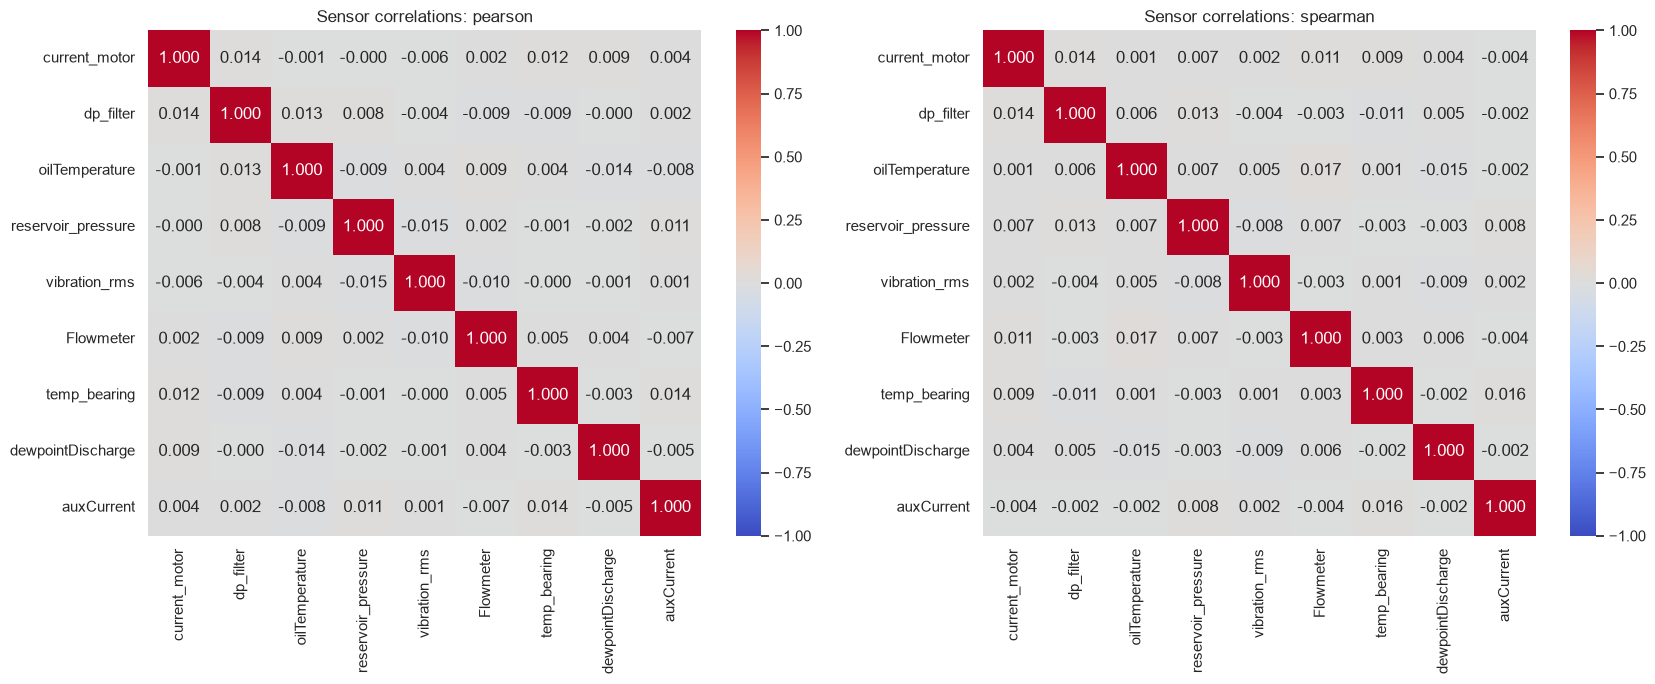

,current_motor,dp_filter,oilTemperature,reservoir_pressure,vibration_rms,Flowmeter,temp_bearing,dewpointDischarge,auxCurrent
complete_pair_count,,,,,,,,,
current_motor,15080,14481,15080,15080,14486,15080,15080,15080,15080
dp_filter,14481,14481,14481,14481,13956,14481,14481,14481,14481
oilTemperature,15080,14481,15080,15080,14486,15080,15080,15080,15080
reservoir_pressure,15080,14481,15080,15080,14486,15080,15080,15080,15080
vibration_rms,14486,13956,14486,14486,14486,14486,14486,14486,14486
Flowmeter,15080,14481,15080,15080,14486,15080,15080,15080,15080
temp_bearing,15080,14481,15080,15080,14486,15080,15080,15080,15080
dewpointDischarge,15080,14481,15080,15080,14486,15080,15080,15080,15080
auxCurrent,15080,14481,15080,15080,14486,15080,15080,15080,15080


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for method, ax in zip(["pearson", "spearman"], axes):
    sns.heatmap(readings[sensor_cols].corr(method=method), annot=True, fmt=".3f",
                cmap="coolwarm", vmax=1, vmin=-1, ax=ax)
    ax.set_title(f"Sensor correlations: {method}")
plt.tight_layout()
plt.show()
present = readings[sensor_cols].notna().astype("int64")
display((present.T @ present).rename_axis("complete_pair_count"))

,,Spearman correlation
oilTemperature,Flowmeter,0.017000
temp_bearing,auxCurrent,0.015544
oilTemperature,dewpointDischarge,-0.014742
current_motor,dp_filter,0.013668
dp_filter,reservoir_pressure,0.013200
current_motor,Flowmeter,0.010973
dp_filter,temp_bearing,-0.010579
current_motor,temp_bearing,0.009146
vibration_rms,dewpointDischarge,-0.009132
reservoir_pressure,vibration_rms,-0.008485


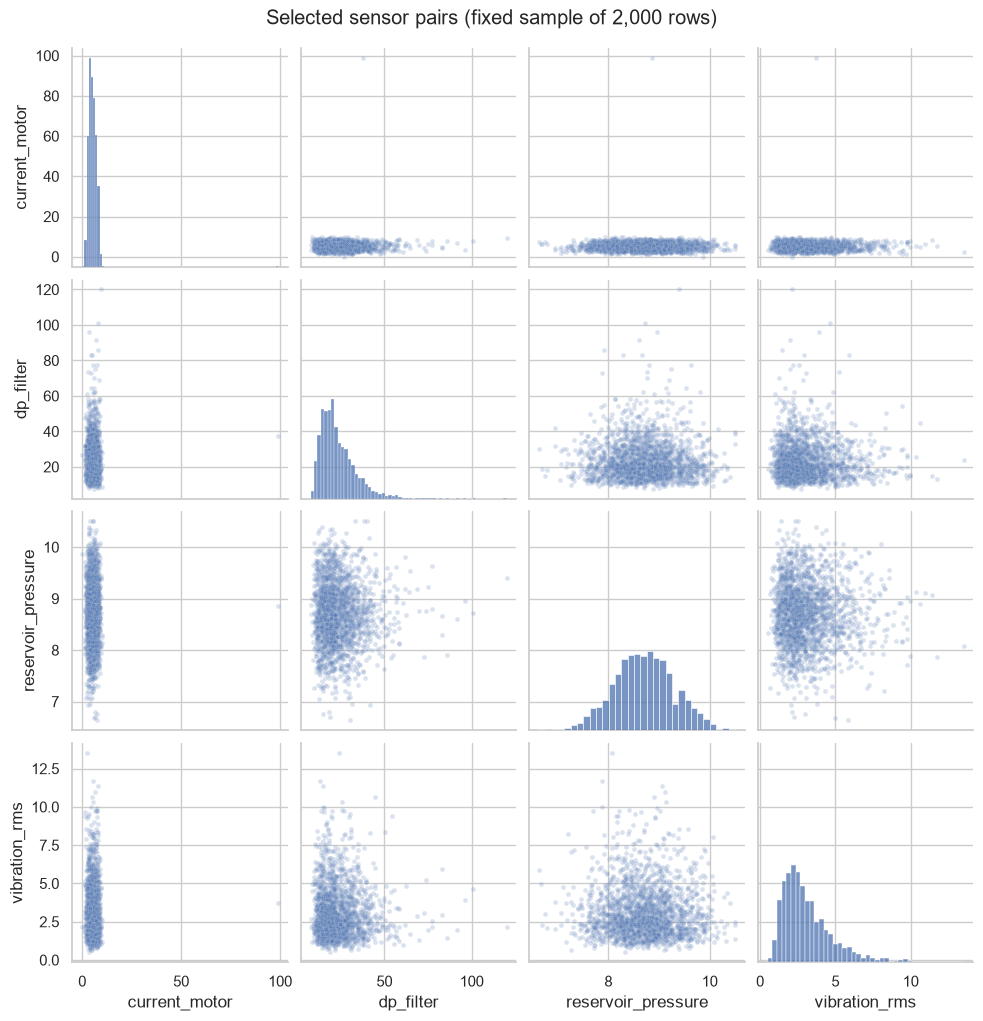

In [17]:
corr = readings[sensor_cols].corr(method="spearman")
pair_correlations = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
display(pair_correlations.sort_values(key=lambda values: values.abs(), ascending=False)
        .head(10).rename("Spearman correlation").to_frame())

pairplot_cols = ["current_motor", "dp_filter", "reservoir_pressure", "vibration_rms"]
pairplot_sample = readings[pairplot_cols].sample(min(2000, len(readings)), random_state=42)
sns.pairplot(pairplot_sample, diag_kind="hist", plot_kws={"alpha": 0.2, "s": 12})
plt.suptitle("Selected sensor pairs (fixed sample of 2,000 rows)", y=1.02)
plt.show()

,hours_service,commissionYear
hours_service,1.000000,-0.986403
commissionYear,-0.986403,1.000000


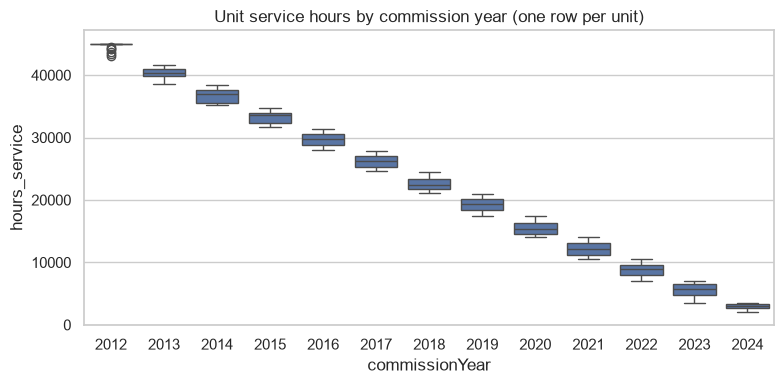

fleet_code,FA,FB,FC,FD,FE
model_code,,,,,
APU-12,105,104,98,104,94
APU-15,87,94,120,115,99
APU-20,81,88,103,103,90
XC-7,112,100,87,115,101


fleet_code,FA,FB,FC,FD,FE
model_code,,,,,
APU-12,0.208,0.206,0.194,0.206,0.186
APU-15,0.169,0.183,0.233,0.223,0.192
APU-20,0.174,0.189,0.222,0.222,0.194
XC-7,0.217,0.194,0.169,0.223,0.196


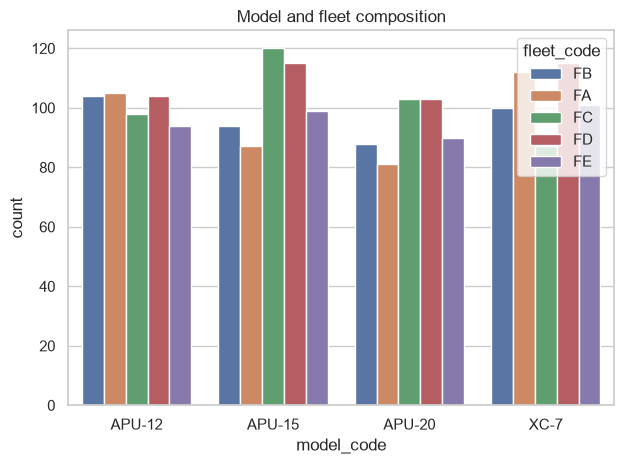

In [18]:
display(units[["hours_service", "commissionYear"]].corr(method="spearman"))
plt.figure(figsize=(8, 4))
sns.boxplot(data=units, x="commissionYear", y="hours_service")
plt.title("Unit service hours by commission year (one row per unit)")
plt.tight_layout()
plt.show()

display(pd.crosstab(units["model_code"], units["fleet_code"]))
display(pd.crosstab(units["model_code"], units["fleet_code"], normalize="index").round(3))
sns.countplot(data=units, x="model_code", hue="fleet_code")
plt.title("Model and fleet composition")
plt.tight_layout()
plt.show()

The sensor-to-sensor relationships are very weak, the largest absolute Pearson correlation is about 0.015 and the largest absolute Spearman correlation is about 0.017. The selected pair plots do not show an obvious trend. This does not prove that the sensors are independent, nonlinear relationships may still exist.

Service hours and commission year have a very strong negative Spearman correlation (−0.986) at the unit level, earlier commission years generally correspond to more service hours. These candidate predictors carry largely overlapping information in this snapshot. The model/fleet crosstab has broadly distributed counts across all combinations, with no obvious exclusive mapping. Duplicates and suspicious sensor codes are still present, so these relationships should be rechecked after justified cleaning.

### D – Relationships between the target and potential predictors

We compare per-class descriptive statistics and distributions, then summarize numerical associations with `failure`. These are descriptive associations, not conclusions or statistical hypothesis tests. The sensor comparisons use every reading, unit metadata comparisons use the validated left join.

failure                            0         1
current_motor      count   13209.000  1871.000
                   mean        5.335     4.918
                   median      5.151     4.545
                   std         3.912     2.714
dp_filter          count   12945.000  1536.000
                   mean       23.554    27.929
                   median     21.013    24.704
                   std        10.832    13.832
oilTemperature     count   13209.000  1871.000
                   mean       51.646    49.787
                   median     55.015    54.849
                   std        61.141    74.122
reservoir_pressure count   13209.000  1871.000
                   mean        8.717     8.549
                   median      8.714     8.532
                   std         0.596     0.585
vibration_rms      count   12932.000  1554.000
                   mean        3.083     3.282
                   median      2.699     2.851
                   std         1.653     1.716
Flowmeter          count   13209.000  1871.000
                   mean       28.108    27.599
                   median     28.079    27.446
                   std         3.957     4.124
temp_bearing       count   13209.000  1871.000
                   mean       64.675    66.864
                   median     64.659    66.686
                   std         8.046     8.152
dewpointDischarge  count   13209.000  1871.000
                   mean        7.918     8.694
                   median      7.947     8.719
                   std         3.465     3.539
auxCurrent         count   13209.000  1871.000
                   mean        2.483     2.643
                   median      2.487     2.626
                   std         0.824     0.811

,Spearman correlation with failure
dp_filter,0.1083
reservoir_pressure,-0.0934
temp_bearing,0.0855
dewpointDischarge,0.0695
current_motor,-0.0633
auxCurrent,0.0616
Flowmeter,-0.0428
vibration_rms,0.0411
oilTemperature,-0.0074


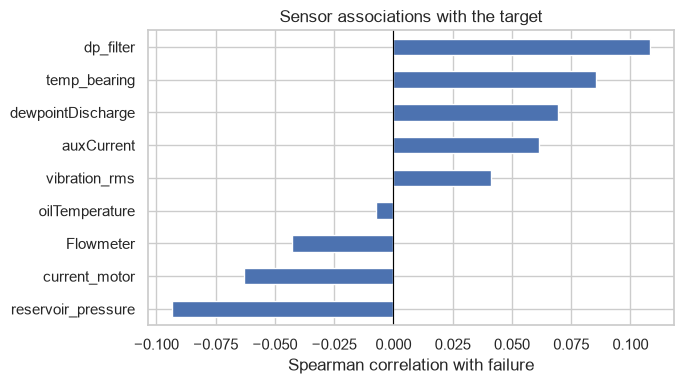

In [19]:
display(readings.groupby("failure")[sensor_cols].agg(["count", "mean", "median", "std"]).T.round(3))
target_correlations = readings[sensor_cols + ["failure"]].corr(method="spearman")["failure"].drop("failure")
display(target_correlations.sort_values(key=lambda values: values.abs(), ascending=False)
        .rename("Spearman correlation with failure").to_frame().round(4))
target_correlations.sort_values().plot.barh(figsize=(7, 4))
plt.xlabel("Spearman correlation with failure")
plt.title("Sensor associations with the target")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

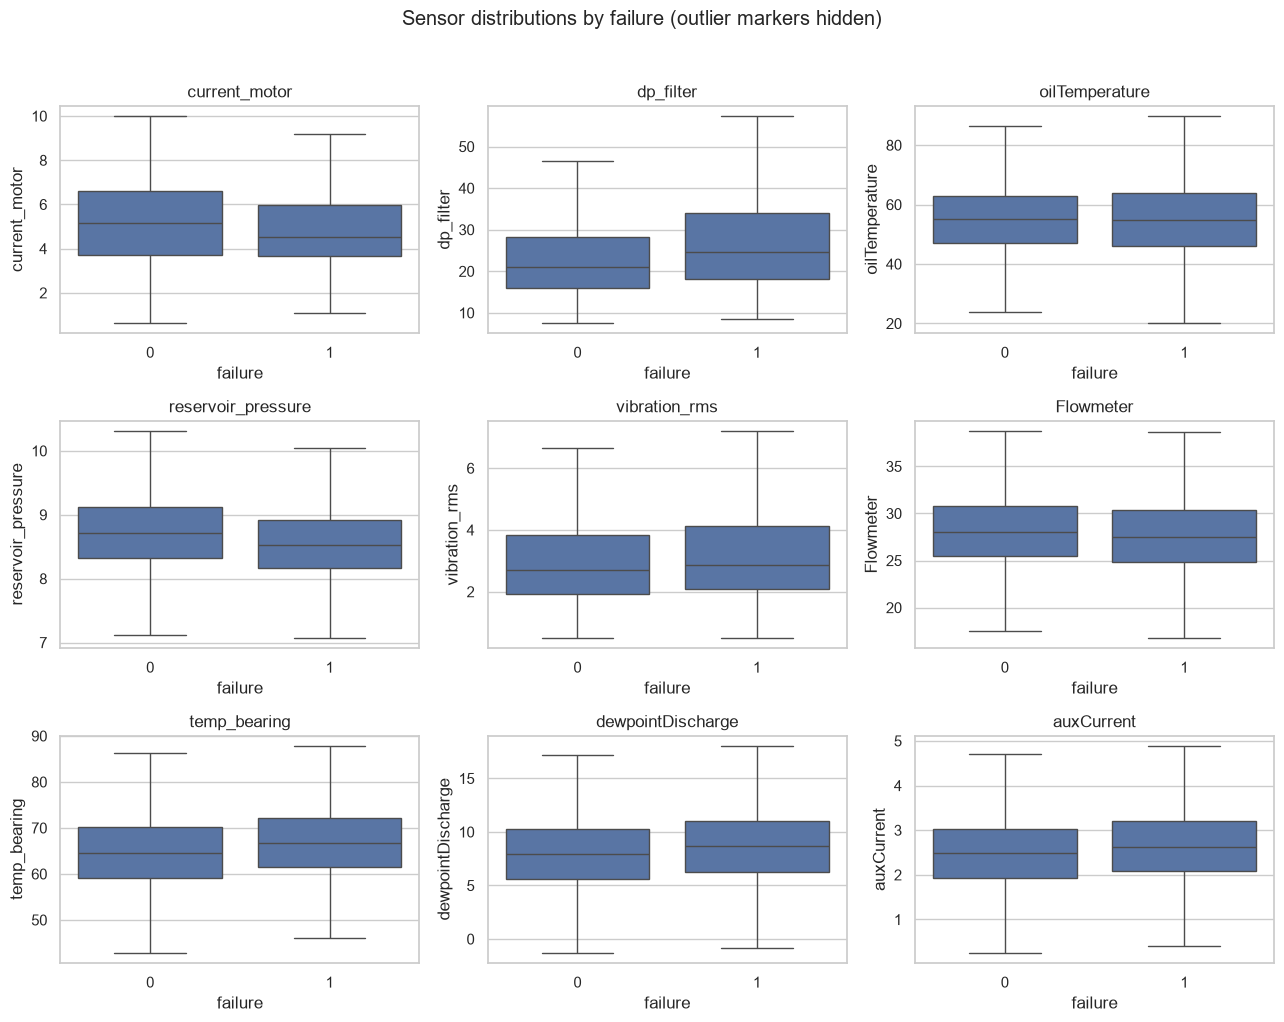

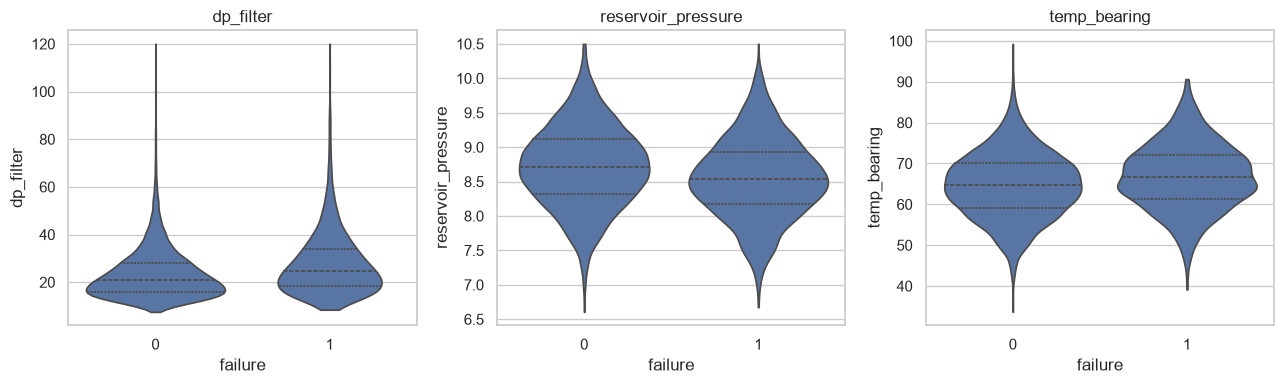

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for col, ax in zip(sensor_cols, axes.flat):
    sns.boxplot(data=readings, x="failure", y=col, order=[0, 1], showfliers=False, ax=ax)
    ax.set_title(col)
plt.suptitle("Sensor distributions by failure (outlier markers hidden)", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for col, ax in zip(["dp_filter", "reservoir_pressure", "temp_bearing"], axes):
    sns.violinplot(data=readings, x="failure", y=col, order=[0, 1],
                   cut=0, inner="quart", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Failure rows have a higher median `dp_filter` (24.70 vs 21.01), lower median `reservoir_pressure` (8.53 vs 8.71), and higher median `temp_bearing` (66.69 vs 64.66). These are the strongest sensor associations here, but their absolute Spearman correlations remain modest (about 0.108, 0.093, and 0.086).

`dewpointDischarge`, `auxCurrent`, and `vibration_rms` tend to be higher with failure, while motor current and flow tend to be lower. The class distributions overlap considerably; no single sensor visibly separates the classes. Oil temperature medians are very similar, and its raw means are distorted by the -999 values.

The box plots hide outlier markers for readability. Statistics and full-range plots above include the extremes.

failure                       0         1
hours_service  count   12364.00   1782.00
               mean    13779.14  17207.19
               median  11774.20  14494.10
               std      8232.15  10089.97
commissionYear count   13072.00   1864.00
               mean     2020.58   2019.62
               median   2021.00   2020.00
               std         2.36      2.86

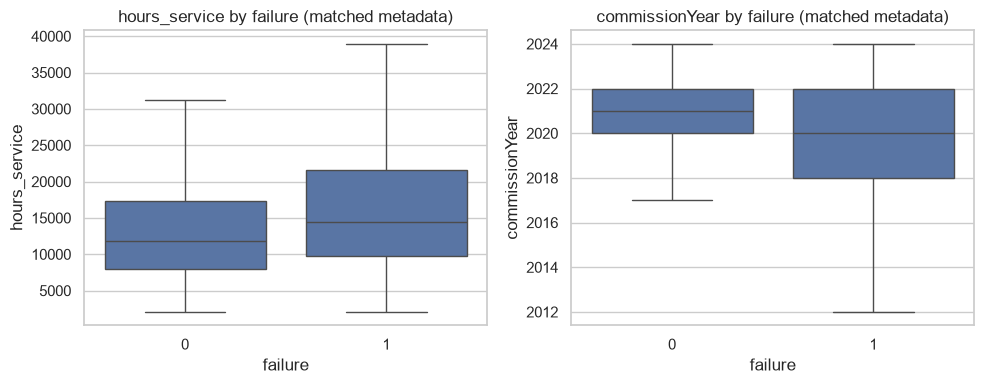

model_code


,failure_0,failure_1,reading_rows,failure_percent
model_code,,,,
<unmatched unit>,137,7,144,4.86
APU-12,3333,480,3813,12.59
APU-15,3332,468,3800,12.32
APU-20,3062,465,3527,13.18
XC-7,3345,451,3796,11.88


fleet_code


,failure_0,failure_1,reading_rows,failure_percent
fleet_code,,,,
<unmatched unit>,137,7,144,4.86
FA,2478,364,2842,12.81
FB,2515,359,2874,12.49
FC,2743,359,3102,11.57
FD,2789,405,3194,12.68
FE,2547,377,2924,12.89


class_duty


,failure_0,failure_1,reading_rows,failure_percent
class_duty,,,,
1,195,39,234,16.67
2,121,15,136,11.03
3,88,7,95,7.37
H,61,5,66,7.58
L,149,35,184,19.02
N,95,13,108,12.04
heavy,139,10,149,6.71
light,148,19,167,11.38
med,120,17,137,12.41


commissionYear


,failure_0,failure_1,reading_rows,failure_percent
commissionYear,,,,
2012.0,202,74,276,26.81
2013.0,101,37,138,26.81
2014.0,149,63,212,29.72
2015.0,123,24,147,16.33
2016.0,318,60,378,15.87
2017.0,269,69,338,20.41
2018.0,799,164,963,17.03
2019.0,1190,216,1406,15.36
2020.0,1831,282,2113,13.35


In [21]:
display(eda.groupby("failure")[["hours_service", "commissionYear"]]
        .agg(["count", "mean", "median", "std"]).T.round(2))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for col, ax in zip(["hours_service", "commissionYear"], axes):
    sns.boxplot(data=eda, x="failure", y=col, order=[0, 1], showfliers=False, ax=ax)
    ax.set_title(f"{col} by failure (matched metadata)")
plt.tight_layout()
plt.show()

category_target_tables = {}
for col in ["model_code", "fleet_code", "class_duty", "commissionYear"]:
    # Explicit category for unmatched metadata; no original values are overwritten.
    values = eda[col].astype("string").fillna("<unmatched unit>")
    table = pd.crosstab(values, eda["failure"]).reindex(columns=[0, 1], fill_value=0)
    table.columns = ["failure_0", "failure_1"]
    table["reading_rows"] = table["failure_0"] + table["failure_1"]
    table["failure_percent"] = 100 * table["failure_1"] / table["reading_rows"]
    category_target_tables[col] = table
    print(col)
    display(table.round(2))

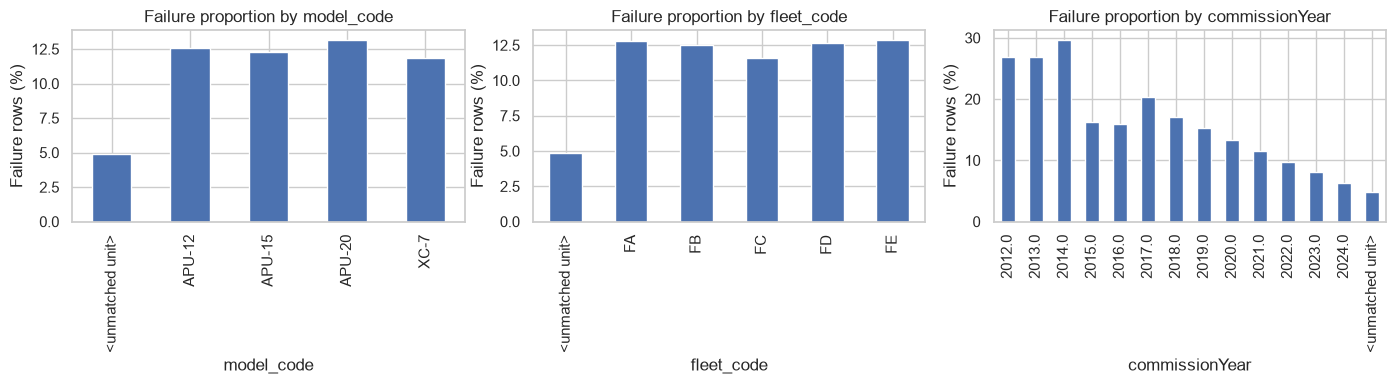

,count,sum,failure_percent
tsCycle_date,,,
2023-01,1268,152,11.99
2023-02,1137,139,12.23
2023-03,1172,142,12.12
2023-04,1267,130,10.26
2023-05,1315,175,13.31
2023-06,1267,139,10.97
2023-07,1330,177,13.31
2023-08,1316,175,13.30
2023-09,1255,147,11.71


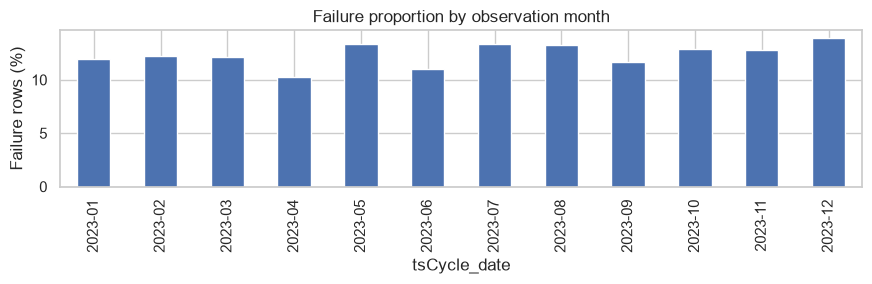

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for col, ax in zip(["model_code", "fleet_code", "commissionYear"], axes):
    category_target_tables[col]["failure_percent"].plot.bar(ax=ax)
    ax.set_ylabel("Failure rows (%)")
    ax.set_title(f"Failure proportion by {col}")
plt.tight_layout()
plt.show()

monthly_target = readings_eda.groupby(readings_eda["tsCycle_date"].dt.to_period("M"))["failure"].agg(["count", "sum", "mean"])
monthly_target["failure_percent"] = 100 * monthly_target["mean"]
display(monthly_target.drop(columns="mean").round(2))
monthly_target["failure_percent"].plot.bar(figsize=(9, 3))
plt.ylabel("Failure rows (%)")
plt.title("Failure proportion by observation month")
plt.tight_layout()
plt.show()

Matched failure rows have a higher median service-hours value (14,494.1 vs 11,774.2) and a higher mean (17,207.2 vs 13,779.1). Commission-year proportions suggest more failures among some older units.

The four model codes have similar failure proportions (roughly 12–13%). Fleet and duty-class tables allow further inspection, but category support varies, and duty aliases have not yet been corrected. The month table checks whether target proportions vary over the observed year.

Each percentage is a proportion of reading rows, not the percentage of units that failed or the number of separate failure events. Repeated observations of the same unit are not independent. Gateway signal/firmware are not compared as prediction inputs here because the gateway snapshot is later than every reading; their historical availability is unconfirmed.

### E – Initial thoughts and decisions for the project

Before deciding which metadata to use, we check its chronology against the observation date. These checks only diagnose the available snapshot.

In [23]:
matched = eda.loc[eda["unit_match"].eq("both")]
chronology_checks = pd.Series({
    "Readings with commission year later than cycle year": matched["commissionYear"].gt(matched["tsCycle_date"].dt.year).sum(),
    "Readings with overhaulLast later than cycle date": matched["overhaulLast_date"].gt(matched["tsCycle_date"]).sum(),
    "Gateway lastSeen later than the latest reading": gateways_eda["lastSeen_date"].gt(readings_eda["tsCycle_date"].max()).sum(),
}, name="flagged_records")
display(chronology_checks)
display(matched.loc[matched["commissionYear"].gt(matched["tsCycle_date"].dt.year),
                    ["unitId", "tsCycle_date", "commissionYear", "overhaulLast_date"]].head())
display(pd.crosstab(eda["unit_match"], eda["failure"]))

Readings with commission year later than cycle year      286
Readings with overhaulLast later than cycle date        2168
Gateway lastSeen later than the latest reading         16000
Name: flagged_records, dtype: int64

,unitId,tsCycle_date,commissionYear,overhaulLast_date
157,U01304,2023-12-25 00:00:00,2024.0,2023-01-12
164,U01304,2023-09-03 00:00:00,2024.0,2023-01-12
169,U01946,2023-10-11 00:00:00,2024.0,2016-01-02
202,U00310,2023-04-01 00:00:00,2024.0,2017-05-27
244,U00053,2023-10-10 21:34:00,2024.0,2019-09-13


failure,0,1
unit_match,,
left_only,137,7
both,13072,1864


# TODO: CONCLUSION OF SECTION 1.1